# a5 - Survival analysis
learn-customer-retention-with-phoebe - by Phoebe Fu

Non-subscription customers never tell you they churned. We define churn as 90 days of inactivity
at the snapshot date, treat still-possibly-active customers as CENSORED (we know they survived at
least this long, not their final lifetime), and let Kaplan-Meier and Cox handle the censoring
honestly instead of throwing those customers away.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Resolve repo root whether the kernel starts in the repo root or in notebooks/
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
assert (ROOT / "data").exists(), "run this notebook from the repo root or notebooks/"
np.random.seed(42)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

orders = pd.read_csv(ROOT / "data" / "ecommerce_orders.csv", parse_dates=["order_date"])
snapshot = orders["order_date"].max() + pd.Timedelta(days=1)
CHURN_WINDOW = 90

cust = orders.groupby("customer_id").agg(
    first=("order_date", "min"), last=("order_date", "max"),
    n_orders=("order_date", "count"), segment=("segment", "first"))
# duration = first-to-last order span, +1 day so single-order customers get a positive duration
cust["duration"] = (cust["last"] - cust["first"]).dt.days + 1
# event observed (churned) unless the last order is within 90d of snapshot (still may be alive)
cust["event"] = ((snapshot - cust["last"]).dt.days >= CHURN_WINDOW).astype(int)
print(f"snapshot {snapshot.date()}, churn window {CHURN_WINDOW}d")
print(cust["event"].value_counts().rename({1: "churned (event)", 0: "censored (maybe alive)"}))

snapshot 2026-07-29, churn window 90d
event
churned (event)           2514
censored (maybe alive)    1516
Name: count, dtype: int64


## Kaplan-Meier: the survival curve

S(t) = probability a customer's ordering lifetime exceeds t days. Censored customers contribute
to the denominator while they are observed and then drop out without counting as deaths - that is
the entire trick.

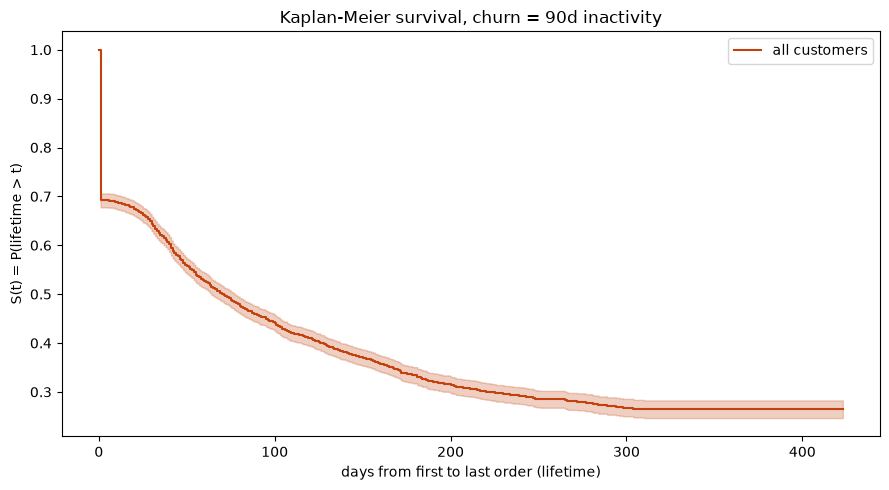

median customer lifetime: 71 days


In [2]:
kmf = KaplanMeierFitter()
kmf.fit(cust["duration"], event_observed=cust["event"], label="all customers")
fig, ax = plt.subplots(figsize=(9, 5))
kmf.plot_survival_function(ax=ax, color="#C2410C")
ax.set_xlabel("days from first to last order (lifetime)")
ax.set_ylabel("S(t) = P(lifetime > t)")
ax.set_title(f"Kaplan-Meier survival, churn = {CHURN_WINDOW}d inactivity")
plt.tight_layout()
plt.show()
print(f"median customer lifetime: {kmf.median_survival_time_:.0f} days")

## Retail vs wholesale

Two curves, one formal comparison. The log-rank test asks whether the two survival curves could
plausibly be the same; with wholesalers ordering every month, they cannot.

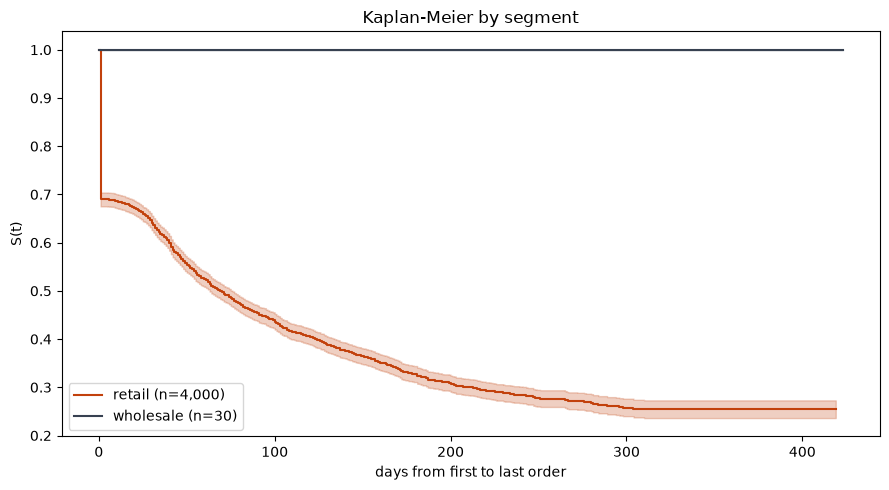

log-rank test statistic = 42.5, p = 7.05e-11
median lifetime, retail:    69 days
median lifetime, wholesale: inf (inf means the curve never crossed 50% - most wholesalers are censored, still alive)


In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
groups = {"retail": "#C2410C", "wholesale": "#374151"}
fits = {}
for seg, color in groups.items():
    sub = cust[cust["segment"] == seg]
    f = KaplanMeierFitter().fit(sub["duration"], sub["event"], label=f"{seg} (n={len(sub):,})")
    f.plot_survival_function(ax=ax, color=color)
    fits[seg] = f
ax.set_xlabel("days from first to last order")
ax.set_ylabel("S(t)")
ax.set_title("Kaplan-Meier by segment")
plt.tight_layout()
plt.show()

r = cust[cust["segment"] == "retail"]; w = cust[cust["segment"] == "wholesale"]
lr = logrank_test(r["duration"], w["duration"], r["event"], w["event"])
print(f"log-rank test statistic = {lr.test_statistic:.1f}, p = {lr.p_value:.2e}")
print(f"median lifetime, retail:    {fits['retail'].median_survival_time_:.0f} days")
print(f"median lifetime, wholesale: {fits['wholesale'].median_survival_time_} "
      "(inf means the curve never crossed 50% - most wholesalers are censored, still alive)")

## Cox proportional hazards: which traits change the churn hazard

Cox regression gives a hazard ratio per covariate: exp(coef) > 1 means the trait raises the
instantaneous churn risk, < 1 means it protects. Covariates here: log of the first order's value,
number of orders in the customer's first month, and the wholesale flag. A small penalizer keeps
the fit stable given the tiny, near-immortal wholesale segment.

In [4]:
first_orders = orders.sort_values("order_date").groupby("customer_id").first()
first_month_counts = (orders.join(cust["first"], on="customer_id")
                      .loc[lambda d: (d["order_date"] - d["first"]).dt.days < 30]
                      .groupby("customer_id").size())
cox_df = pd.DataFrame({
    "duration": cust["duration"],
    "event": cust["event"],
    "log_first_order_value": np.log(first_orders["order_value"]),
    "first_month_orders": first_month_counts.reindex(cust.index).fillna(0),
    "wholesale": (cust["segment"] == "wholesale").astype(int)})

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_df, duration_col="duration", event_col="event")
cph.print_summary(decimals=3)
hr = np.exp(cph.params_)
print("\nhazard ratios:")
print(hr.round(3))

<lifelines.CoxPHFitter: fitted with 4030 total observations, 1516 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 4030
number of events observed = 2514
   partial log-likelihood = -19294.556
         time fit was run = 2026-08-28 01:32:40 UTC

---
                        coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                                     
log_first_order_value -0.018      0.982      0.033           -0.084            0.047                0.920                1.048
first_month_orders    -0.472      0.624      0.033           -0.537           -0.406                0.584                0.666
wholesale             -1.098      0.333      0.405           -1.891           -0.305                0.151                0.737

                        cmp to       z       p   -log2(p)
covariate                                                
log_first_order_value    0.000  -0.549   0.583      0.779
first_month_orders       0.000 -14.123 <0.0005    148.029
wholesale                0.000  -2.714   0.007      7.234
---
Concordance = 0.624
Partial AIC = 38595.111
log-likelihood ratio test = 279.198 on 3 df
-log2(p) of ll-ratio test = 197.657


hazard ratios:
covariate
log_first_order_value   0.982
first_month_orders      0.624
wholesale               0.333
Name: coef, dtype: float64


**Reading one hazard ratio**: the `wholesale` coefficient is strongly negative, so its hazard
ratio exp(coef) is far below 1 - being a wholesaler multiplies the instantaneous churn hazard by
that factor, i.e. wholesalers are dramatically less likely to stop ordering at any moment. Among
retail-style covariates, each extra first-month order also lowers the hazard (ratio below 1):
early repeat behavior predicts a longer life, which is exactly the behavioral-cohort story from
a4 in survival language.

## The churn window is a modeling choice

Rerun the whole thing at 60 and 120 day inactivity windows. A shorter window declares more
customers dead (more events, earlier), a longer window keeps more of them censored. The median
lifetime moves with the definition - so report the window next to every survival number.

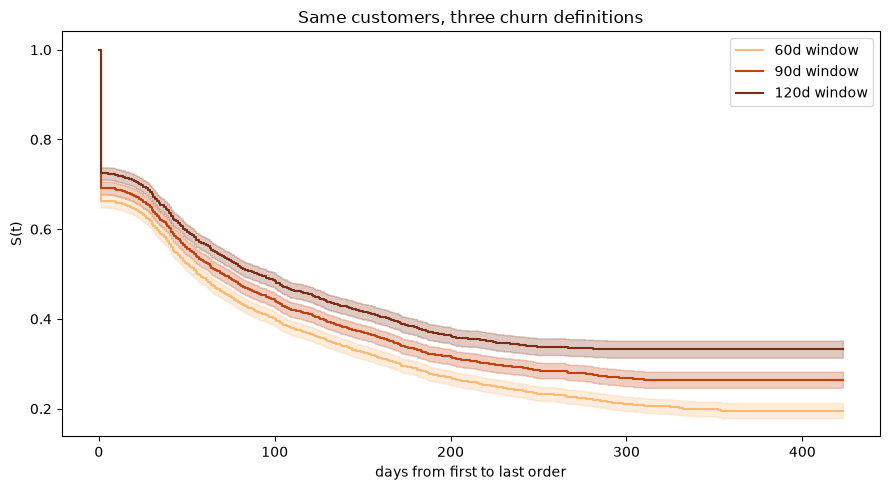

60d inactivity window: median lifetime = 57.0 days
90d inactivity window: median lifetime = 71.0 days
120d inactivity window: median lifetime = 91.0 days


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
medians = {}
for win, color in [(60, "#FDBA74"), (90, "#C2410C"), (120, "#7C2D12")]:
    ev = ((snapshot - cust["last"]).dt.days >= win).astype(int)
    f = KaplanMeierFitter().fit(cust["duration"], ev, label=f"{win}d window")
    f.plot_survival_function(ax=ax, color=color)
    medians[win] = f.median_survival_time_
ax.set_xlabel("days from first to last order")
ax.set_ylabel("S(t)")
ax.set_title("Same customers, three churn definitions")
plt.tight_layout()
plt.show()
for win, m in medians.items():
    print(f"{win}d inactivity window: median lifetime = {m} days")